# CCAI9016 Tutorial 3: Seeing Traffic with AI

_by Han Boyu_ (u3012643@connect.hku.hk)

This notebook uses a pre-trained computer vision model to detect vehicles in live snapshots from the Hong Kong Transport Department's traffic cameras, puts the results on the OpenStreetMap road network, and checks how reliable the model is. It includes the following steps

- load the locations of all traffic cameras (open data from DATA.GOV.HK)
- choose your study area
- download the latest snapshot of each camera
- detect vehicles with a pre-trained YOLO model
- look at what the model sees
- map the vehicle counts on the OSM road network
- compare the model with your own counts
- fix a counting function written by a classmate

### How to use this notebook

Run the cells in order, from top to bottom. **Shift + Enter** runs a cell and moves to the next one. Lines in the code are marked in three ways.

- `# [FILL IN]` you must set this value yourself. The cell stops with a `FillInError` that tells you what is missing until you do.
- `# [OPTIONAL]` you may change this value.
- `# [KEEP]` leave this line as it is.

Press Ctrl + F (Cmd + F on a Mac) and search for `FILL IN` to find all of them. The assignment guide (PDF) explains each one. Every step that needs your input has ✏️ in its title.

**Important.** The cameras upload a new picture every two minutes, so Step 3 gives you a different set of images every time you run it. Once you start counting vehicles by hand in Step 7, do **not** run Step 3 again. Run the notebook in daytime, because most night images are too dark for the model.

In [ ]:
# Install the two libraries that are not pre-installed in Colab (takes about a minute)
!pip install ultralytics osmnx --quiet

import io, os, hashlib, datetime
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import requests
import osmnx as ox
from PIL import Image
from ultralytics import YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 4.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [ ]:
#@title Helper functions (run this cell, you do not need to change it) { display-mode: "form" }

HKT = datetime.timezone(datetime.timedelta(hours=8))   # Hong Kong time
HK_CRS = "EPSG:2326"                                   # Hong Kong 1980 Grid, units in metres
HEADERS = {"User-Agent": "Mozilla/5.0 (CCAI9016 tutorial notebook)"}
CAMERA_LIST_URLS = [
    "https://static.data.gov.hk/td/traffic-snapshot-images/code/Traffic_Camera_Locations_En.xml",
    "https://static.data.gov.hk/td/traffic-snapshot-images/code/Traffic_Camera_Locations_Tc.xml",
]
VEHICLE_CLASSES = ["car", "bus", "truck", "motorcycle"]   # set again in Step 4
CLASS_COLORS = {"car": "#00BFFF", "bus": "#FFD700", "truck": "#FF8C00", "motorcycle": "#7CFC00"}


class FillInError(Exception):
    """A value marked [FILL IN] is still missing or not valid."""


def require(ok, message):
    """Stop the cell with a clear message if a value you have to fill in is missing."""
    if not ok:
        raise FillInError(message)


def load_camera_list():
    """Download the Transport Department's list of traffic cameras as a GeoDataFrame."""
    for url in CAMERA_LIST_URLS:
        try:
            resp = requests.get(url, headers=HEADERS, timeout=30)
            resp.raise_for_status()
            df = pd.read_xml(io.BytesIO(resp.content), parser="etree")
            break
        except Exception as e:
            print("Could not read", url, "|", type(e).__name__)
    else:
        raise RuntimeError("The camera list is not available. Check the internet connection and run the cell again.")
    for col in ["latitude", "longitude"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["latitude", "longitude"]).reset_index(drop=True)
    return gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["longitude"], df["latitude"]), crs="EPSG:4326")


def fetch_snapshots(cams, timeout=15):
    """Download the latest snapshot of every camera in `cams`.
    Returns a dict {camera key: image} and a table with the download status of each camera."""
    images, records = {}, []
    for key, url in zip(cams["key"], cams["url"]):
        rec = {"key": key, "status": "ok", "md5": None}
        try:
            # We download the file ourselves every time. If YOLO is given the URL directly,
            # it keeps a local copy and reuses the old picture when the cell is run again.
            resp = requests.get(url, headers=HEADERS, timeout=timeout)
            resp.raise_for_status()
            images[key] = Image.open(io.BytesIO(resp.content)).convert("RGB")
            rec["md5"] = hashlib.md5(resp.content).hexdigest()
        except Exception:
            rec["status"] = "download failed"
        records.append(rec)
    status = pd.DataFrame(records)
    # A camera that is offline sends back a "No Service" picture. When several cameras return
    # exactly the same file, we treat it as this placeholder and drop those cameras.
    dup = status["md5"].notna() & status.duplicated("md5", keep=False)
    status.loc[dup, "status"] = "no service (identical image)"
    for key in status.loc[dup, "key"]:
        images.pop(key, None)
    return images, status


def count_vehicles(detections, keys, conf_threshold, classes=None):
    """Vehicle count of each image, i.e. boxes with a vehicle class and confidence >= threshold."""
    classes = VEHICLE_CLASSES if classes is None else classes
    d = detections[(detections["conf"] >= conf_threshold) & detections["name"].isin(classes)]
    return d.groupby("key").size().reindex(list(keys), fill_value=0)


def main_road_type(highway):
    """Simplify the OSM highway tag, e.g. 'trunk_link' becomes 'trunk'."""
    if isinstance(highway, list):
        highway = highway[0]
    if not isinstance(highway, str):
        return "unknown"
    return highway.replace("_link", "")


def check_keys(keys, step, minimum):
    """Keep only camera keys that were used in Step 4 and check that enough are left."""
    require(isinstance(keys, (list, tuple)), f"{step}. Write the camera keys as a list, e.g. [\"KEY1\", \"KEY2\"].")
    known = set(cams_used["key"])
    unknown = [k for k in keys if k not in known]
    if unknown:
        print("Not among the cameras used in Step 4, skipped", unknown,
              "(copy the keys from the list printed by the cell above)")
    keys = [k for k in keys if k in known]
    require(len(keys) >= minimum, f"{step}. Put at least {minimum} camera keys from the list printed by the cell above into the list.")
    return keys


def print_keys(keys):
    """Print the camera keys as a Python list that can be copied into the next cell."""
    print("Camera keys you can choose from (copy the ones you want, with their quotes)")
    print("[" + ", ".join(f'"{k}"' for k in keys) + "]")


def draw_detections(ax, key, conf_threshold, classes=None, det=None, img=None, labels=True):
    """Show one snapshot with its boxes.
    classes=None draws the vehicle classes only, classes="all" draws every class the model found."""
    det = detections if det is None else det
    img = images[key] if img is None else img
    d = det[(det["key"] == key) & (det["conf"] >= conf_threshold)]
    if classes != "all":
        d = d[d["name"].isin(VEHICLE_CLASSES if classes is None else classes)]
    ax.imshow(img)
    for _, b in d.iterrows():
        color = CLASS_COLORS.get(b["name"], "#FF3B3B")   # classes that are not vehicles are drawn in red
        ax.add_patch(patches.Rectangle((b["x1"], b["y1"]), b["x2"] - b["x1"], b["y2"] - b["y1"],
                                       fill=False, edgecolor=color, linewidth=1.5))
        if labels:
            ax.text(b["x1"], b["y1"], f"{b['name']} {b['conf']:.2f}", fontsize=6, va="bottom",
                    bbox=dict(facecolor=color, alpha=0.75, pad=1, edgecolor="none"))
    ax.set_title(f"{key} ({len(d)} boxes)", fontsize=10)
    ax.set_axis_off()
    return len(d)


print("Helper functions loaded.")

Helper functions loaded.


## Step 1. Load the traffic camera locations

The Transport Department publishes the locations of about 1,000 traffic cameras on [DATA.GOV.HK](https://data.gov.hk/en-data/dataset/hk-td-tis_2-traffic-snapshot-images). Each camera has a `key` (for example H106F), a description, its latitude and longitude, and the web address (`url`) of its latest snapshot. The map and the table below help you choose your study area in Step 2.

Nothing to fill in here.

Traffic cameras in Hong Kong 1013


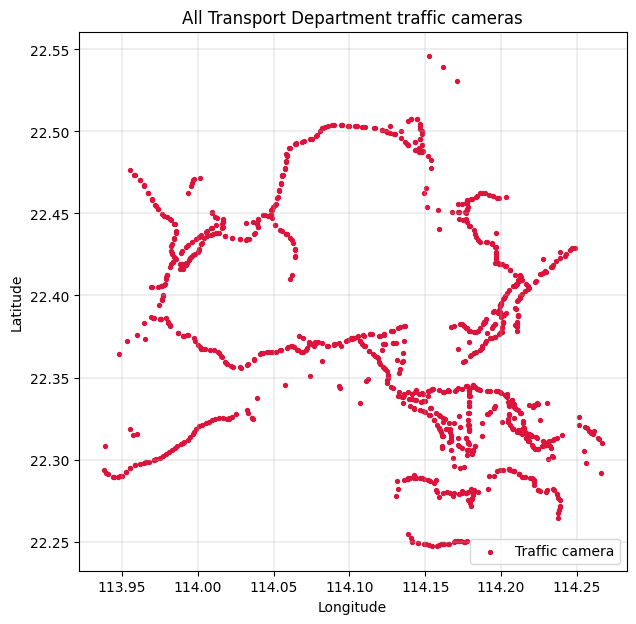

,cameras
district,
Yuen Long,147
Sha Tin,129
Tsuen Wan,104
Tuen Mun,84
Kwun Tong,77
North,57
Tai Po,57
Sham Shui Po,50
Yau Tsim Mong,43


In [ ]:
cams_all = load_camera_list()
print("Traffic cameras in Hong Kong", len(cams_all))

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(cams_all["longitude"], cams_all["latitude"], s=8, color="crimson", label="Traffic camera")
ax.set_aspect(1 / np.cos(np.radians(22.35)))
ax.ticklabel_format(useOffset=False)
ax.grid(True, linewidth=0.3)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("All Transport Department traffic cameras")
ax.legend(loc="lower right")
plt.show()

cams_all["district"].value_counts().rename("cameras").to_frame()

## Step 2. Choose your study area ✏️

**You fill in** `location_point` and `radius_m`.

Pick the centre of your study area and a search radius, as in Tutorial 2. To get the coordinates of a place, right-click it in Google Maps and click the two numbers at the top of the menu (this copies them). Paste them between the brackets, latitude first. The notebook uses the cameras inside the circle, the closest ones first, up to `MAX_CAMERAS`. Your area needs **at least 10 cameras**, and `radius_m` must be at most 5000 so that the road network download in Step 6 stays fast. Use the map in Step 1 to see where the cameras are.

Cameras in your study area 40


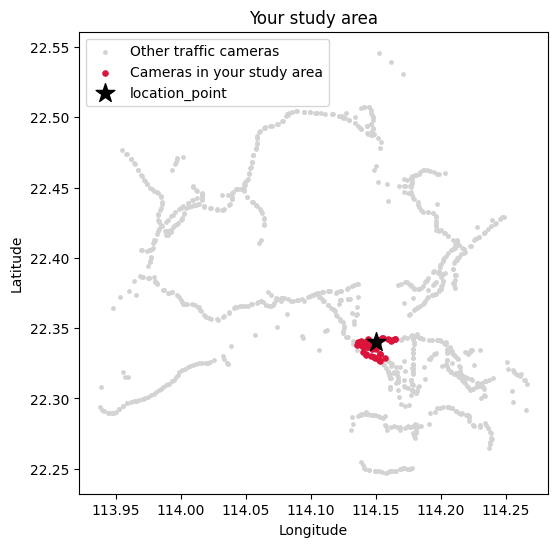

,key,district,description,dist_m
0,AID07131,Sham Shui Po,Ching Cheung Road near Dragon lndustrial Build...,182.0
1,AID07204,Sham Shui Po,Ching Cheung Road near Dragon lndustrial Build...,229.0
2,K305F,Sham Shui Po,Cheung Sha Wan Road near Kwong Cheung Street [...,245.0
3,AID07130,Sham Shui Po,Ching Cheung Road near Caritas Medical Centre ...,259.0
4,AID07205,Sham Shui Po,Ching Cheung Road near Caritas Medical Centre ...,309.0
5,AID07203,Sham Shui Po,Ching Cheung Road near International School - ...,440.0
6,K802F,Sham Shui Po,Ching Cheung Road near Caritas Medical Center ...,482.0
7,AID05216,Sham Shui Po,West Kowloon Corridor near The Pacifica -South...,507.0
8,AID05121,Sham Shui Po,West Kowloon Corridor near Lai Chi Kok MTR Sta...,513.0
9,AID07129,Sham Shui Po,Lung Cheung Road near Monte Carlton - Westboun...,554.0


In [ ]:
location_point = (22.34, 114.15)   # [FILL IN] (latitude, longitude) of the centre of your area, e.g. (22.xxxx, 114.xxxx)
radius_m = 3000         # [FILL IN] search radius in metres, at most 5000
MAX_CAMERAS = 40        # [OPTIONAL] upper limit on the number of cameras, keeps the run time short

require(isinstance(location_point, (tuple, list)) and len(location_point) == 2,
        "Step 2. Set location_point to (latitude, longitude), for example copied from Google Maps.")
require(22.1 < location_point[0] < 22.6 and 113.8 < location_point[1] < 114.5,
        "Step 2. location_point is not in Hong Kong. Write it as (latitude, longitude), latitude first.")
require(isinstance(radius_m, (int, float)) and 0 < radius_m <= 5000,
        "Step 2. Set radius_m to a distance in metres, larger than 0 and at most 5000.")

# distance in metres from every camera to your location_point
center = gpd.GeoSeries(gpd.points_from_xy([location_point[1]], [location_point[0]]), crs="EPSG:4326").to_crs(HK_CRS).iloc[0]
cams_all["dist_m"] = cams_all.to_crs(HK_CRS).distance(center).round(0)
cams = cams_all[cams_all["dist_m"] <= radius_m].sort_values("dist_m").head(MAX_CAMERAS).reset_index(drop=True)
print("Cameras in your study area", len(cams))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(cams_all["longitude"], cams_all["latitude"], s=6, color="lightgrey", label="Other traffic cameras")
ax.scatter(cams["longitude"], cams["latitude"], s=14, color="crimson", label="Cameras in your study area")
ax.scatter(location_point[1], location_point[0], marker="*", s=200, color="black", label="location_point")
ax.set_aspect(1 / np.cos(np.radians(location_point[0])))
ax.ticklabel_format(useOffset=False)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Your study area")
ax.legend(loc="best")
plt.show()

require(len(cams) >= 10, f"Step 2. Only {len(cams)} cameras in your area. Increase radius_m or move location_point, then run this cell again.")
cams[["key", "district", "description", "dist_m"]]

## Step 3. Download the latest snapshots

Nothing to fill in here, but **run this cell only once**.

Each camera uploads a new 320 x 240 picture every two minutes, so every run of this cell gives you a new set of images. The notebook records the time of your run (report it in your submission) and saves the images in the `snapshots` folder (Files panel on the left). Your hand counts in Step 7 must refer to these images, so do not run this cell again after you start counting. Look at the thumbnails. If a picture is broken, frozen or completely dark, add its key to `EXCLUDE_KEYS` in Step 4.

Snapshots downloaded at 2026-09-28 22:03 (Hong Kong time)
status
ok                              37
no service (identical image)     3


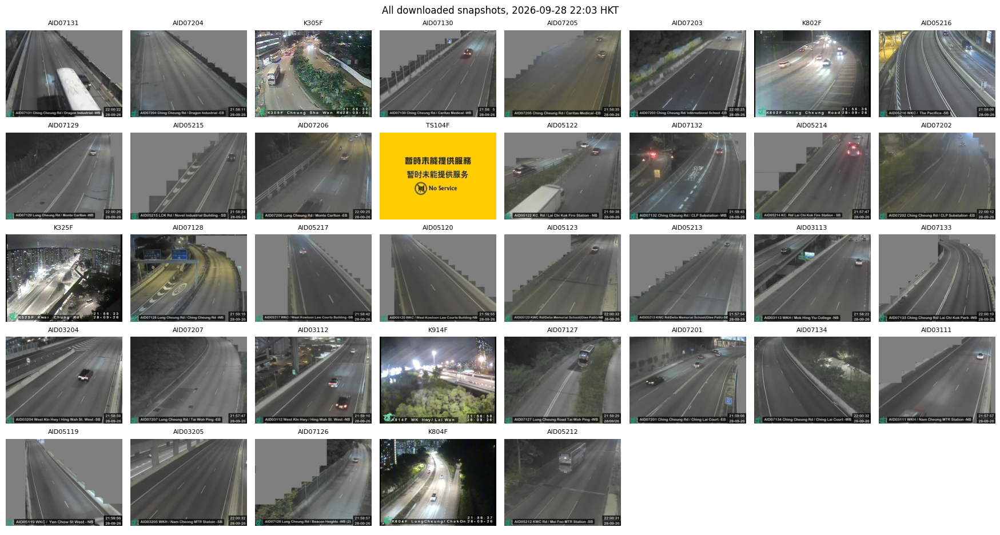

In [ ]:
RUN_TIME = datetime.datetime.now(HKT)
images, download_status = fetch_snapshots(cams)

os.makedirs("snapshots", exist_ok=True)
for key, img in images.items():
    img.save(f"snapshots/{key}_{RUN_TIME:%Y%m%d_%H%M}.jpg")

print(f"Snapshots downloaded at {RUN_TIME:%Y-%m-%d %H:%M} (Hong Kong time)")
print(download_status["status"].value_counts().to_string())

keys = list(images)
if keys:
    ncols = 8
    nrows = int(np.ceil(len(keys) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.2 * ncols, 1.9 * nrows), squeeze=False)
    for ax in axes.flat:
        ax.set_axis_off()
    for ax, key in zip(axes.flat, keys):
        ax.imshow(images[key])
        ax.set_title(key, fontsize=8)
    fig.suptitle(f"All downloaded snapshots, {RUN_TIME:%Y-%m-%d %H:%M} HKT")
    plt.tight_layout()
    plt.show()

## Step 4. Detect vehicles with a pre-trained AI model ✏️

**You fill in** `CONF_THRESHOLD`. Optionally `EXCLUDE_KEYS`.

We use **YOLO** ("You Only Look Once"), a deep learning model for object detection. It was trained on [COCO](https://cocodataset.org), a collection of about 118,000 everyday photos labelled with 80 kinds of objects (person, car, bus, truck, traffic light, dog, and so on). We do not train anything here. We only ask the trained model what it sees.

For every image the model returns a list of **boxes**. Each box has a class name and a **confidence** between 0 and 1. A box counts as a vehicle if its class is in `VEHICLE_CLASSES` and its confidence is at least a threshold $\theta$ (`CONF_THRESHOLD`). The vehicle count of image $j$ is therefore

$$\hat{y}_j(\theta)=\sum_{b \in B_j} \mathbf{1}[s_b \ge \theta]\;\mathbf{1}[c_b \in V]$$

where $B_j$ is the set of boxes in image $j$, $s_b$ and $c_b$ are the confidence and the class of box $b$, and $V$ is the set of vehicle classes.

For your first run, set `CONF_THRESHOLD` to 0.25. In Step 7 you will choose your own $\theta$. Then set `CONF_THRESHOLD` to that value and run Steps 4 to 8 again (not Step 3), so that all your figures use your chosen $\theta$.

In [ ]:
CONF_THRESHOLD = 0.25    # [FILL IN] confidence threshold θ between 0 and 1 (0.25 for your first run, later your chosen θ)
EXCLUDE_KEYS = ['TS104F']        # [OPTIONAL] keys of broken, frozen or dark snapshots from Step 3, e.g. ["KEY1", "KEY2"]
MODEL_NAME = "yolo11n.pt"                                 # [KEEP] "n" = nano, the smallest and fastest YOLO11 model
VEHICLE_CLASSES = ["car", "bus", "truck", "motorcycle"]   # [KEEP] must match the counting rule in Step 7

require(isinstance(CONF_THRESHOLD, (int, float)) and 0 < CONF_THRESHOLD < 1,
        "Step 4. Set CONF_THRESHOLD to a number between 0 and 1, e.g. 0.25 for your first run.")

# ---- the AI part ----
model = YOLO(MODEL_NAME)       # downloads the trained model (a few MB) the first time

def detect(model, images, min_conf=0.05):
    # Run the detector on every image and return one row per box.
    # We keep boxes down to a confidence of 0.05 so that we can try other thresholds later.
    rows = []
    for key, img in images.items():
        result = model(img, conf=min_conf, verbose=False)[0]
        for box, cls, conf in zip(result.boxes.xyxy.tolist(), result.boxes.cls.tolist(), result.boxes.conf.tolist()):
            rows.append({"key": key, "name": result.names[int(cls)], "conf": float(conf),
                         "x1": box[0], "y1": box[1], "x2": box[2], "y2": box[3]})
    return pd.DataFrame(rows, columns=["key", "name", "conf", "x1", "y1", "x2", "y2"])

use_keys = [k for k in images if k not in EXCLUDE_KEYS]
detections = detect(model, {k: images[k] for k in use_keys})

cams_used = cams[cams["key"].isin(use_keys)].reset_index(drop=True)
cams_used["n_vehicle"] = count_vehicles(detections, cams_used["key"], CONF_THRESHOLD).values

# save the counts, you need this file for Extra Credit 1
counts_file = f"counts_{RUN_TIME:%Y%m%d_%H%M}.csv"
(cams_used.assign(model=MODEL_NAME, theta=CONF_THRESHOLD)
          [["key", "description", "n_vehicle", "model", "theta"]].to_csv(counts_file, index=False))

print(f"{len(detections)} boxes found in {len(use_keys)} images. Vehicle counts saved to {counts_file}")
print("\nMost frequent classes among all boxes (any confidence above 0.05)")
print(detections["name"].value_counts().head(10).to_string())
cams_used[["key", "description", "n_vehicle"]].sort_values("n_vehicle", ascending=False)

198 boxes found in 36 images. Vehicle counts saved to counts_20260928_2203.csv

Most frequent classes among all boxes (any confidence above 0.05)
name
car              131
clock             14
train              9
traffic light      9
person             8
bus                8
truck              7
airplane           2
tv                 2
bird               2


,key,description,n_vehicle
11,AID05122,Kwai Chung Road near Lai Chi Kok Fire Station-...,5
21,AID03113,West Kowloon Highway near SKH St. Andrew's Pri...,5
6,K802F,Ching Cheung Road near Caritas Medical Center ...,5
28,AID07201,Ching Cheung Road near Ching Lai Court - Eastb...,4
10,AID07206,Lung Cheung Road near Monte Carlton - Eastboun...,3
25,AID03112,West Kowloon Highway near Hing Wah Street West...,3
12,AID07132,Ching Cheung Road near CLP Substation - Westbo...,2
3,AID07130,Ching Cheung Road near Caritas Medical Centre ...,2
27,AID07127,Lung Cheung Road Tai Woh Ping - Westbound [AID...,2
4,AID07205,Ching Cheung Road near Caritas Medical Centre ...,2


## Step 5. Look at what the AI sees ✏️

**You fill in** `SHOW_KEYS` in the second cell.

The first cell shows every snapshot with the vehicles the model found (busiest first) and prints the list of camera keys. Look at the pictures and choose at least three for Figure A, including at least one where the model does well and one where it makes mistakes (missed vehicles, boxes on things that are not vehicles, or wrong classes). Copy their keys from the printed list into `SHOW_KEYS` in the second cell. The second cell draws them large, with the class and confidence of every box.

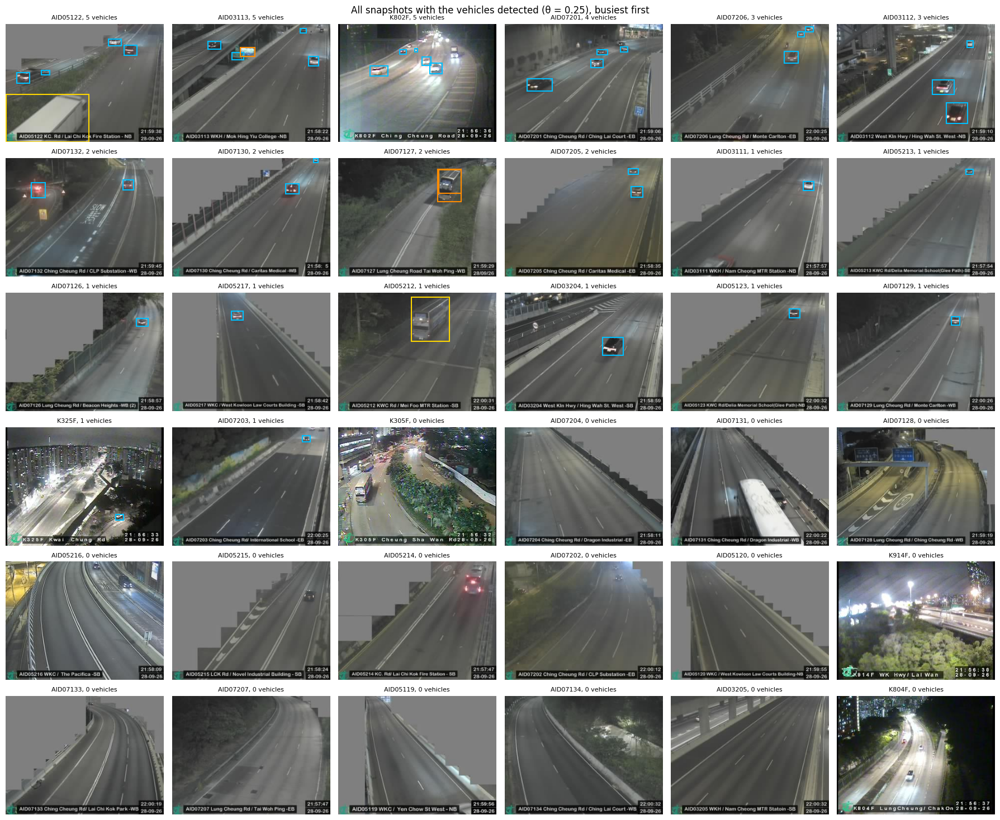

Camera keys you can choose from (copy the ones you want, with their quotes)
["AID05122", "AID03113", "K802F", "AID07201", "AID07206", "AID03112", "AID07132", "AID07130", "AID07127", "AID07205", "AID03111", "AID05213", "AID07126", "AID05217", "AID05212", "AID03204", "AID05123", "AID07129", "K325F", "AID07203", "K305F", "AID07204", "AID07131", "AID07128", "AID05216", "AID05215", "AID05214", "AID07202", "AID05120", "K914F", "AID07133", "AID07207", "AID05119", "AID07134", "AID03205", "K804F"]


In [ ]:
# Overview of all snapshots with the vehicles the model found. Nothing to fill in here.
keys_all = cams_used.sort_values("n_vehicle", ascending=False)["key"].tolist()
ncols = 6
nrows = int(np.ceil(len(keys_all) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2.5 * nrows), squeeze=False)
for ax in axes.flat:
    ax.set_axis_off()
for ax, key in zip(axes.flat, keys_all):
    n = draw_detections(ax, key, CONF_THRESHOLD, labels=False)
    ax.set_title(f"{key}, {n} vehicles", fontsize=8)
fig.suptitle(f"All snapshots with the vehicles detected (θ = {CONF_THRESHOLD}), busiest first")
plt.tight_layout()
plt.show()
print_keys(keys_all)

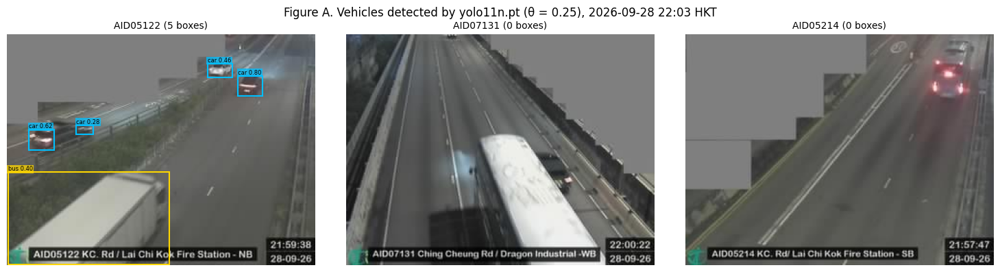

In [ ]:
SHOW_KEYS = ["AID05122", "AID07131", "AID05214"]    # [FILL IN] at least 3 keys from the list printed above, written like ["KEY1", "KEY2", "KEY3"]

keys_to_show = check_keys(SHOW_KEYS, "Step 5", 3)
ncols = 3
nrows = int(np.ceil(len(keys_to_show) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
for ax in axes.flat:
    ax.set_axis_off()
for ax, key in zip(axes.flat, keys_to_show):
    draw_detections(ax, key, CONF_THRESHOLD)
fig.suptitle(f"Figure A. Vehicles detected by {MODEL_NAME} (θ = {CONF_THRESHOLD}), {RUN_TIME:%Y-%m-%d %H:%M} HKT")
plt.tight_layout()
plt.show()

## Step 6. Put the counts on the OSM road network

Nothing to fill in here.

As in Tutorial 2, we download data from OpenStreetMap, this time the drivable road network around your study area, and match every camera to its nearest road. The `highway` tag of that road gives the road type (motorway, trunk, primary, secondary, ...). To measure distances in metres, the network and the cameras are first projected to the Hong Kong 1980 Grid (EPSG:2326). The download can take up to a minute.

In [ ]:
G = ox.graph_from_point(location_point, dist=radius_m + 300, network_type="drive")
edges = ox.graph_to_gdfs(G, nodes=False)
edges["road_type"] = edges["highway"].apply(main_road_type)

# nearest road to each camera, computed in metres
Gp = ox.project_graph(G, to_crs=HK_CRS)
cams_xy = cams_used.to_crs(HK_CRS)
nearest, dist = ox.distance.nearest_edges(Gp, X=cams_xy.geometry.x.values, Y=cams_xy.geometry.y.values, return_dist=True)
cams_used["road_type"] = [main_road_type(Gp.edges[u, v, k].get("highway")) for u, v, k in nearest]
cams_used["dist_to_road_m"] = np.round(dist, 1)

cams_used[["key", "description", "road_type", "dist_to_road_m", "n_vehicle"]]

,key,description,road_type,dist_to_road_m,n_vehicle
0,AID07131,Ching Cheung Road near Dragon lndustrial Build...,trunk,3.6,0
1,AID07204,Ching Cheung Road near Dragon lndustrial Build...,trunk,1.1,0
2,K305F,Cheung Sha Wan Road near Kwong Cheung Street [...,unclassified,2.7,0
3,AID07130,Ching Cheung Road near Caritas Medical Centre ...,trunk,6.7,2
4,AID07205,Ching Cheung Road near Caritas Medical Centre ...,trunk,6.8,2
5,AID07203,Ching Cheung Road near International School - ...,trunk,6.1,1
6,K802F,Ching Cheung Road near Caritas Medical Center ...,trunk,8.7,5
7,AID05216,West Kowloon Corridor near The Pacifica -South...,tertiary,0.9,0
8,AID07129,Lung Cheung Road near Monte Carlton - Westboun...,trunk,8.3,1
9,AID05215,Lai Chi Kok Road near Novel Industrial Buildin...,trunk,5.6,0


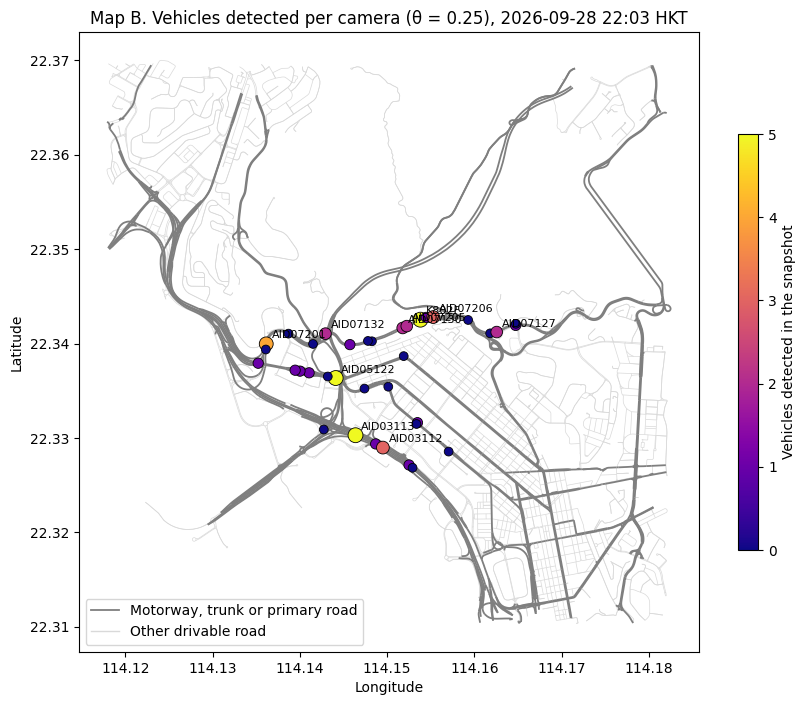

In [ ]:
N_LABELS = 10     # [OPTIONAL] how many cameras get a label on the map (the ones with the most vehicles)

MAJOR = ["motorway", "trunk", "primary"]
fig, ax = plt.subplots(figsize=(10, 9))
edges[~edges["road_type"].isin(MAJOR)].plot(ax=ax, color="#d9d9d9", linewidth=0.5)
edges[edges["road_type"].isin(MAJOR)].plot(ax=ax, color="#7f7f7f", linewidth=1.3)
sc = ax.scatter(cams_used["longitude"], cams_used["latitude"], c=cams_used["n_vehicle"],
                s=40 + 15 * cams_used["n_vehicle"], cmap="plasma", edgecolor="black", linewidth=0.6, zorder=3)
for _, row in cams_used.nlargest(N_LABELS, "n_vehicle").iterrows():
    ax.annotate(row["key"], (row["longitude"], row["latitude"]), xytext=(4, 4), textcoords="offset points", fontsize=8)
plt.colorbar(sc, ax=ax, shrink=0.6, label="Vehicles detected in the snapshot")
ax.legend(handles=[Line2D([0], [0], color="#7f7f7f", lw=1.3, label="Motorway, trunk or primary road"),
                   Line2D([0], [0], color="#d9d9d9", lw=1.0, label="Other drivable road")], loc="lower left")
ax.set_aspect(1 / np.cos(np.radians(location_point[0])))
ax.ticklabel_format(useOffset=False)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Map B. Vehicles detected per camera (θ = {CONF_THRESHOLD}), {RUN_TIME:%Y-%m-%d %H:%M} HKT")
plt.show()

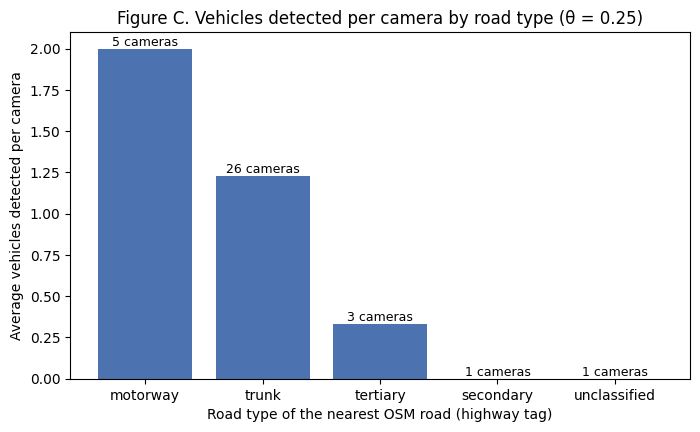

,mean,cameras
road_type,,
motorway,2.000000,5
trunk,1.230769,26
tertiary,0.333333,3
secondary,0.000000,1
unclassified,0.000000,1


In [ ]:
summary = (cams_used.groupby("road_type")["n_vehicle"]
           .agg(mean="mean", cameras="count")
           .sort_values("mean", ascending=False))
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(summary.index, summary["mean"], color="#4C72B0")
for bar, n in zip(bars, summary["cameras"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{n} cameras", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Road type of the nearest OSM road (highway tag)")
ax.set_ylabel("Average vehicles detected per camera")
ax.set_title(f"Figure C. Vehicles detected per camera by road type (θ = {CONF_THRESHOLD})")
plt.show()
summary

## Step 7. How reliable is the AI? ✏️

**You fill in** `COUNT_KEYS` in the second cell and `manual_counts` in the third cell.

A model is only useful if we know how often it is wrong. Here **you** provide the ground truth.

1. The first cell shows all your snapshots without boxes, a table with the number of vehicles the model detected in each (fewest first), and the list of camera keys.
2. Choose at least five snapshots with different conditions, for example busy and quiet roads, near and far views, and at least one snapshot in which the model found few or no vehicles. Copy their keys into `COUNT_KEYS` in the second cell and run it. It shows your snapshots large and prints a line that starts with `manual_counts =`.
3. Count the motor vehicles in each picture by hand. Count every car, taxi, minibus, bus, truck or van and motorcycle that is at least half visible. Do not count trams or bicycles. Count on the raw picture, not on the boxes from Step 5.
4. Copy the printed line into the third cell, replace every `?` by your count, and run it.

With your counts $y_j$ for $n$ images, the second cell computes, for thresholds $\theta$ from 0.05 to 0.90,

$$\text{MAE}(\theta)=\frac{1}{n}\sum_{j=1}^{n}\left|\hat{y}_j(\theta)-y_j\right|, \qquad \text{Bias}(\theta)=\frac{1}{n}\sum_{j=1}^{n}\left(\hat{y}_j(\theta)-y_j\right).$$

MAE is the average size of the error. A positive bias means the model counts too many vehicles, a negative bias means it misses vehicles. After this step, choose your $\theta$, set `CONF_THRESHOLD` in Step 4 to it and run Steps 4 to 8 again (not Step 3).

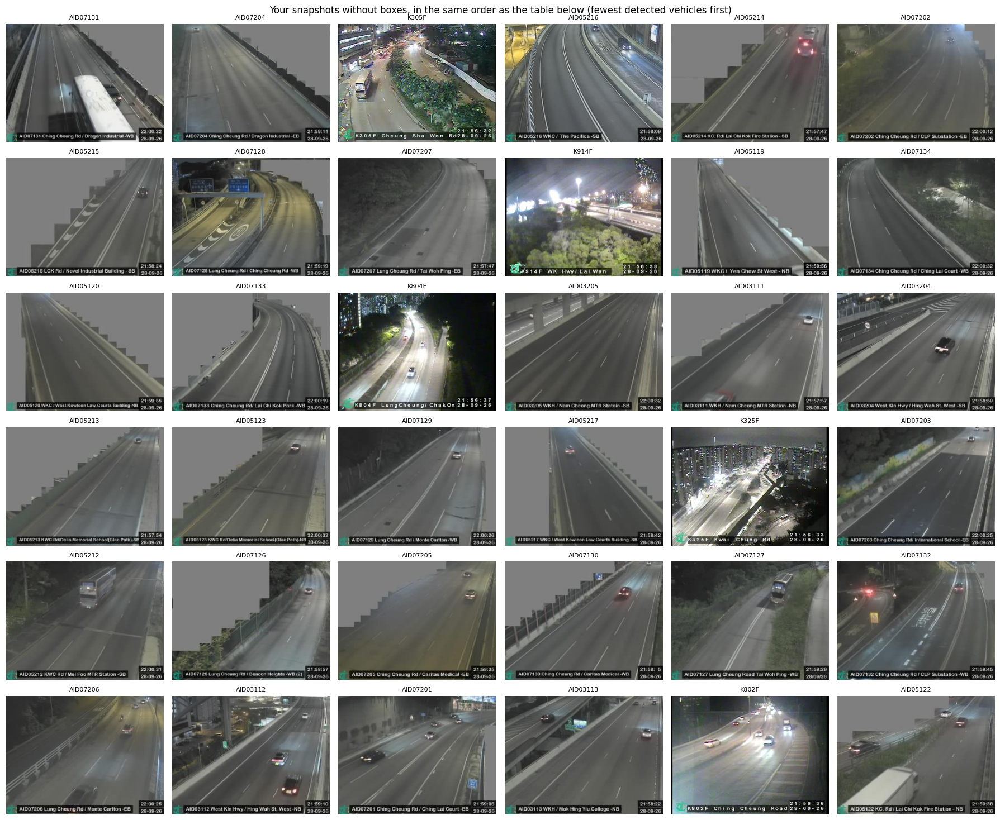

Camera keys you can choose from (copy the ones you want, with their quotes)
["AID07131", "AID07204", "K305F", "AID05216", "AID05214", "AID07202", "AID05215", "AID07128", "AID07207", "K914F", "AID05119", "AID07134", "AID05120", "AID07133", "K804F", "AID03205", "AID03111", "AID03204", "AID05213", "AID05123", "AID07129", "AID05217", "K325F", "AID07203", "AID05212", "AID07126", "AID07205", "AID07130", "AID07127", "AID07132", "AID07206", "AID03112", "AID07201", "AID03113", "K802F", "AID05122"]


,key,description,road_type,vehicles detected by the model
0,AID07131,Ching Cheung Road near Dragon lndustrial Build...,trunk,0
1,AID07204,Ching Cheung Road near Dragon lndustrial Build...,trunk,0
2,K305F,Cheung Sha Wan Road near Kwong Cheung Street [...,unclassified,0
3,AID05216,West Kowloon Corridor near The Pacifica -South...,tertiary,0
4,AID05214,Kwai Chung Road near Lai Chi Kok Fire Station ...,trunk,0
5,AID07202,Ching Cheung Road near CLP Substation - Eastbo...,trunk,0
6,AID05215,Lai Chi Kok Road near Novel Industrial Buildin...,trunk,0
7,AID07128,Lung Cheung Road near Ching Cheung Road - West...,trunk,0
8,AID07207,Lung Cheung Road near Tai Woh Ping - Eastbound...,trunk,0
9,K914F,West Kowloon Highway near Lai Wan Interchange ...,secondary,0


In [ ]:
# Candidates for your hand counts. Nothing to fill in here.
cols = [c for c in ["key", "description", "road_type", "n_vehicle"] if c in cams_used.columns]
candidates = (cams_used[cols].sort_values("n_vehicle").reset_index(drop=True)
              .rename(columns={"n_vehicle": "vehicles detected by the model"}))
keys_all = candidates["key"].tolist()
ncols = 6
nrows = int(np.ceil(len(keys_all) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2.5 * nrows), squeeze=False)
for ax in axes.flat:
    ax.set_axis_off()
for ax, key in zip(axes.flat, keys_all):
    ax.imshow(images[key])
    ax.set_title(key, fontsize=8)
fig.suptitle("Your snapshots without boxes, in the same order as the table below (fewest detected vehicles first)")
plt.tight_layout()
plt.show()
print_keys(keys_all)
candidates

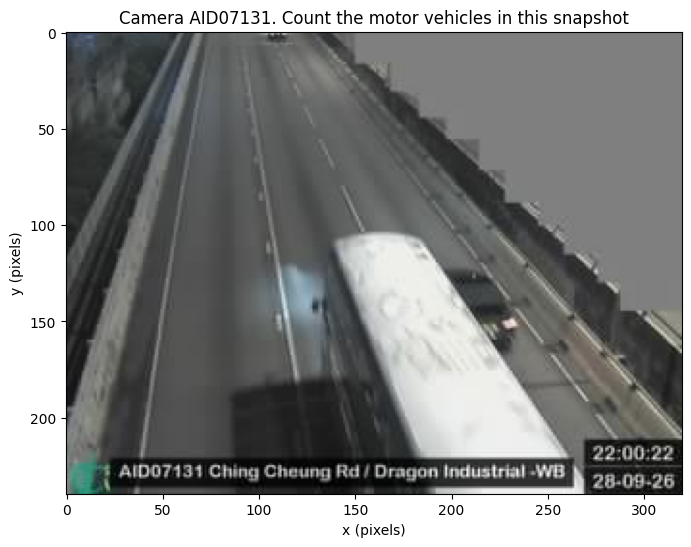

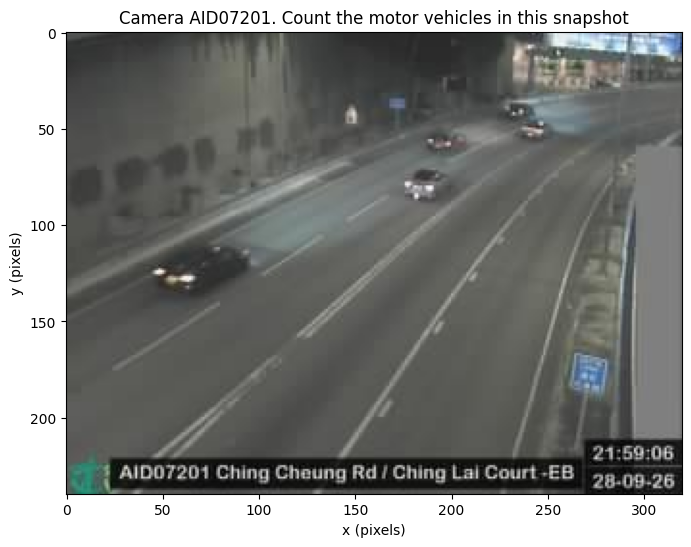

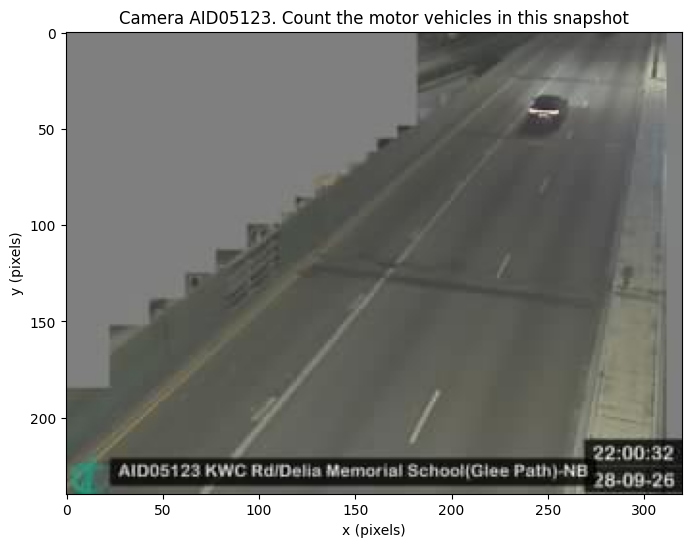

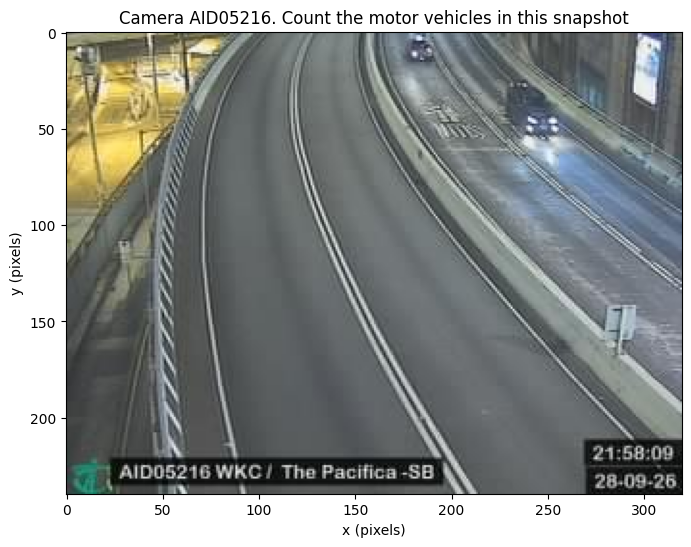

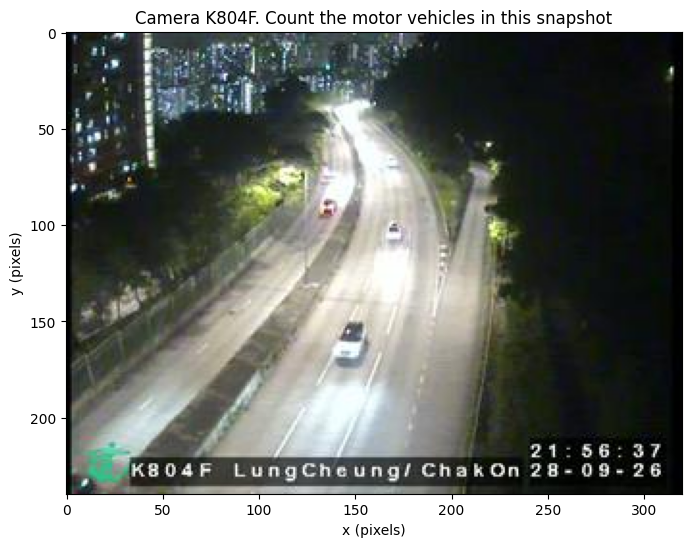

Cameras to count ['AID07131', 'AID07201', 'AID05123', 'AID05216', 'K804F']

Copy the line below into the next cell and replace every ? by your own count
manual_counts = {"AID07131": ?, "AID07201": ?, "AID05123": ?, "AID05216": ?, "K804F": ?}


In [ ]:
COUNT_KEYS = ['AID07131','AID07201','AID05123','AID05216','K804F']    # [FILL IN] at least 5 keys from the list printed above, written like ["KEY1", "KEY2", "KEY3", "KEY4", "KEY5"]

COUNT_KEYS = check_keys(COUNT_KEYS, "Step 7", 5)
for key in COUNT_KEYS:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(images[key])
    ax.set_xlabel("x (pixels)")
    ax.set_ylabel("y (pixels)")
    ax.set_title(f"Camera {key}. Count the motor vehicles in this snapshot")
    plt.show()
print("Cameras to count", COUNT_KEYS)
print("\nCopy the line below into the next cell and replace every ? by your own count")
print("manual_counts = {" + ", ".join(f'"{k}": ?' for k in COUNT_KEYS) + "}")

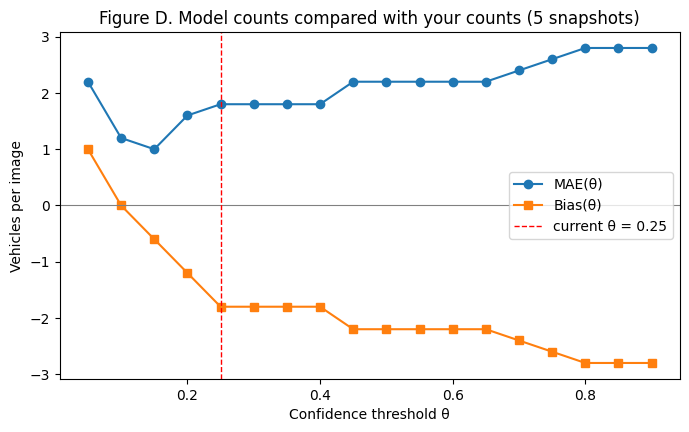

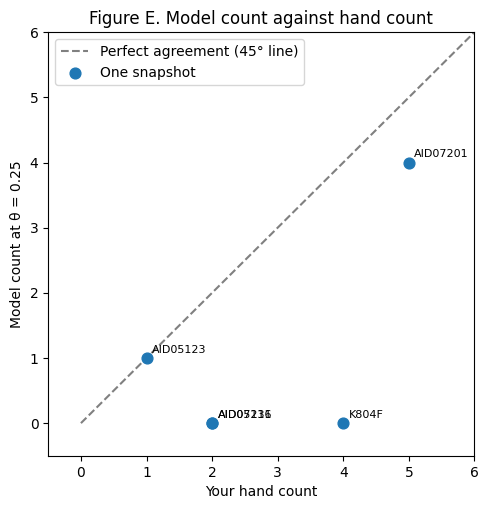

,camera,hand count,model count (θ = 0.25)
0,AID07131,2,0
1,AID07201,5,4
2,AID05123,1,1
3,AID05216,2,0
4,K804F,4,0


,theta,MAE,Bias
0,0.05,2.2,1.0
1,0.10,1.2,0.0
2,0.15,1.0,-0.6
3,0.20,1.6,-1.2
4,0.25,1.8,-1.8
5,0.30,1.8,-1.8
6,0.35,1.8,-1.8
7,0.40,1.8,-1.8
8,0.45,2.2,-2.2
9,0.50,2.2,-2.2


In [21]:
manual_counts = {'AID07131':2,'AID07201':5,'AID05123':1,'AID05216':2,'K804F':4}    # [FILL IN] paste the line printed by the cell above and replace every ? by your count

missing = [k for k in manual_counts if k not in set(cams_used["key"])]
if missing:
    print("These keys are not among the cameras used in Step 4", missing)
require(len(manual_counts) >= 5 and not missing,
        "Step 7. Paste the line printed by the cell above into manual_counts and enter your counts for at least 5 cameras.")
require(all(isinstance(v, int) and v >= 0 for v in manual_counts.values()),
        "Step 7. Every count in manual_counts must be a whole number, 0 or larger.")

keys_m = list(manual_counts)
y = np.array([manual_counts[k] for k in keys_m])
thetas = np.round(np.arange(0.05, 0.91, 0.05), 2)
rows = []
for t in thetas:
    y_hat = count_vehicles(detections, keys_m, t).values
    rows.append({"theta": t, "MAE": np.mean(np.abs(y_hat - y)), "Bias": np.mean(y_hat - y)})
eval_table = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(eval_table["theta"], eval_table["MAE"], marker="o", label="MAE(θ)")
ax.plot(eval_table["theta"], eval_table["Bias"], marker="s", label="Bias(θ)")
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(CONF_THRESHOLD, color="red", linestyle="--", linewidth=1, label=f"current θ = {CONF_THRESHOLD}")
ax.set_xlabel("Confidence threshold θ")
ax.set_ylabel("Vehicles per image")
ax.set_title(f"Figure D. Model counts compared with your counts ({len(keys_m)} snapshots)")
ax.legend()
plt.show()

y_hat = count_vehicles(detections, keys_m, CONF_THRESHOLD).values
lim = max(y.max(), y_hat.max()) + 1
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, lim], [0, lim], linestyle="--", color="grey", label="Perfect agreement (45° line)")
ax.scatter(y, y_hat, s=60, zorder=3, label="One snapshot")
for k, a, b in zip(keys_m, y, y_hat):
    ax.annotate(k, (a, b), xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.set_xlim(-0.5, lim)
ax.set_ylim(-0.5, lim)
ax.set_xlabel("Your hand count")
ax.set_ylabel(f"Model count at θ = {CONF_THRESHOLD}")
ax.set_title("Figure E. Model count against hand count")
ax.legend(loc="upper left")
plt.show()

display(pd.DataFrame({"camera": keys_m, "hand count": y, f"model count (θ = {CONF_THRESHOLD})": y_hat}))
best = eval_table.loc[eval_table["MAE"].idxmin()]
display(eval_table.round(2))

## What to submit

1. Choose your $\theta$ in Step 7, set `CONF_THRESHOLD` in Step 4 to it and run Steps 4 to 7 again (not Step 3).
2. Save the notebook with all its outputs as a PDF (in Colab, File > Print > Save as PDF).
3. Add your written answers and upload one combined PDF to Moodle. Check that all figures are visible in the PDF.